In [1]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, tan, einsum
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import hl2, hl2prime, hl1, hl1prime, graphene_conductivity, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator
from utils import c, hbar, alpha
tau = 6.4*1e-13; # scattering time in seconds

In [2]:
M = 10000
epsilon = 2.1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder
l = 1
j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

In [3]:
sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
sigmas_real = sigmas[0, :] # real part of surface conductivity at CPA
sigmas_imaginary = sigmas[1, :] # imaginary part of surface conductivity at CPA
# The quasistatic dispersion (from the plasmon dispersion)
quasistatic_dispersion = x*(l*epsilon+(l+1))/(l*(l+1))

In [4]:
s_sqrds = abs(e_r_cpa(l, x, epsilon, 1j*(sigmas_real + 1j*sigmas_imaginary)/x))**2
tm_numerator = abs(e_r_cpa_numerator(l, x, epsilon, 1j*(sigmas_real + 1j*sigmas_imaginary)/x))
print("Maximum value for |s|^2: ", s_sqrds.max())
print("Maximum (absolute) value for the cpa numerator", tm_numerator.max())

Maximum value for |s|^2:  3.784555824036611e-14
Maximum (absolute) value for the cpa numerator 5.684341886080801e-13


In [5]:
a = c*tau*x*sigmas_real/sigmas_imaginary; # sphere radii at CPA
hbar_omega = hbar*(sigmas_imaginary/sigmas_real)*(1/tau) # angular frequencies (in eV) at CPA
E_F = (hbar/tau)*(sigmas_real**2+sigmas_imaginary**2)/(4*sigmas_real)/alpha; # Fermi energies in eV at CPA
cpa_idxs = [2000, 3000, 4000]

N = 20
M = 1000
#epsilon_reals = linspace(-3, 3, M) + epsilon # Range of real part of the dielectric function offset by the epsilon for which we calculated cpa
#epsilon_imaginaries = 1j*linspace(-1e-5, 1e-5, M) # Range of imaginary part of the dielectric function
#epsilon_array = epsilon_reals.reshape((M, 1)).repeat(M, axis=1) + epsilon_imaginaries.reshape((1, M)).repeat(M, axis=0)

In [199]:
epsilons_real_cpa_v = []
epsilons_imaginary_cpa_v = [] 
sigma_imaginaries_off_cpa_v = []
for cpa_idx in cpa_idxs:
    print("cpa_idx: ", cpa_idx);
    sigma_imaginaries_off_cpa = sigmas_imaginary[cpa_idx] * (1 + linspace(-0.5, 0.5, N))
    sigma_imaginaries_off_cpa_v.append(sigma_imaginaries_off_cpa)
    epsilons_real_cpa = np.zeros(N)
    epsilons_imaginary_cpa = np.zeros(N)
    for (idx, sigma_imaginary_off_cpa) in enumerate(sigma_imaginaries_off_cpa):
        epsilon_guess = epsilon + (2+epsilon)*(sigma_imaginary_off_cpa/sigmas_imaginary[cpa_idx]-1) 
        #print(epsilon_guess)
        epsilon_reals = linspace(-1, 1, M)+epsilon_guess # Range of real part of the dielectric function offset by the epsilon for which we calculated cpa
        epsilon_imaginaries = 1j*linspace(-1e-3, 1e-3, M) # Range of imaginary part of the dielectric function
        epsilon_array = epsilon_reals.reshape((M, 1)).repeat(M, axis=1) + epsilon_imaginaries.reshape((1, M)).repeat(M, axis=0)
        s_sqrds = abs(e_r_cpa(l, x[cpa_idx], epsilon_array, 1j*(sigmas_real[cpa_idx] + 1j*sigma_imaginary_off_cpa)/x[cpa_idx]))**2
        assert s_sqrds.min() < 0.001
        argmin_idx = unravel_index(s_sqrds.argmin(), (M, M))
        epsilons_real_cpa[idx] = epsilon_array[argmin_idx].real
        epsilons_imaginary_cpa[idx] = epsilon_array[argmin_idx].imag
    epsilons_real_cpa_v.append(epsilons_real_cpa)
    epsilons_imaginary_cpa_v.append(epsilons_imaginary_cpa)

cpa_idx:  2000
cpa_idx:  3000
cpa_idx:  4000


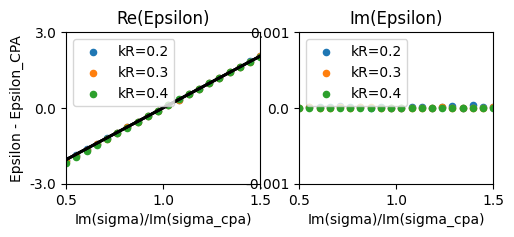

In [200]:
ax1_min = -3+epsilon
ax1_max = 3+epsilon
ax2_min = epsilon_imaginaries.imag.min()
ax2_max = epsilon_imaginaries.imag.max()
s = 20
linewidth = 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14*cm, 5*cm))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    ax1.scatter(sigma_imaginaries_off_cpa_v[idx]/sigmas_imaginary[cpa_idx], epsilons_real_cpa_v[idx], label=f"kR={round(x[cpa_idx], 2)}", s=s)
    ax2.scatter(sigma_imaginaries_off_cpa_v[idx]/sigmas_imaginary[cpa_idx], epsilons_imaginary_cpa_v[idx], label=f"kR={round(x[cpa_idx], 2)}", s=s)
    ax1.plot(sigma_imaginaries_off_cpa_v[idx]/sigmas_imaginary[cpa_idx], epsilon + (2+epsilon)*(sigma_imaginaries_off_cpa_v[idx]/sigmas_imaginary[cpa_idx]-1), linewidth=linewidth, color="black")
ax1.legend()
ax2.legend()
ax1.set_xlim(0.5, 1.5);
ax2.set_xlim(0.5, 1.5);

ax1.set_title("Re(Epsilon)")
ax2.set_title("Im(Epsilon)")

ax1.set_xlabel("Im(sigma)/Im(sigma_cpa)")
ax2.set_xlabel("Im(sigma)/Im(sigma_cpa)");

ax2.set_ylim(ax2_min, ax2_max);
ax1.set_ylim(ax1_min, ax1_max);
ax1.set_yticks([ax1_min, epsilon, ax1_max], (np.array([ax1_min, epsilon, ax1_max]) - epsilon).round(3))
ax2.set_yticks([ax2_min, 0, ax2_max], np.array([ax2_min, 0, ax2_max]).round(3))

ax1.set_xticks([0.5, 1, 1.5]);
ax2.set_xticks([0.5, 1, 1.5]);
ax1.set_ylabel("Epsilon - Epsilon_CPA");
plt.savefig("./paper/track_real_epsilon_off_cpa_analytic.pdf");

In [192]:
N = 20
M = 500
cpa_idxs = [1000, 1500, 2000]
epsilon_reals = linspace(0, 3e-7, M) + epsilon
epsilon_imaginaries = 1j*linspace(-0.01, 0.01, M)
epsilon_array = epsilon_reals.reshape((M, 1)).repeat(M, axis=1) + epsilon_imaginaries.reshape((1, M)).repeat(M, axis=0)

In [193]:
epsilons_real_cpa_v = []
epsilons_imaginary_cpa_v = [] 
sigma_reals_off_cpa_v = []

for (idx, cpa_idx) in enumerate(cpa_idxs):
    print("cpa_idx: ", cpa_idx);
    sigma_reals_off_cpa = sigmas_real[cpa_idx]*(1 + np.linspace(-0.5, 0.5, N))
    sigma_reals_off_cpa_v.append(sigma_reals_off_cpa)

    epsilons_real_cpa = np.zeros(N)
    epsilons_imaginary_cpa = np.zeros(N)
    
    for (idx, sigma_real_off_cpa) in enumerate(sigma_reals_off_cpa):
        s_sqrds = abs(e_r_cpa(l, x[cpa_idx], epsilon_array, 1j*(sigma_real_off_cpa + 1j*sigmas_imaginary[cpa_idx])/x[cpa_idx]))**2
        assert s_sqrds.min() < 1e-3
        argmin_idx = unravel_index(s_sqrds.argmin(), (M, M))
        epsilons_real_cpa[idx] = epsilon_array[argmin_idx].real
        epsilons_imaginary_cpa[idx] = epsilon_array[argmin_idx].imag
    epsilons_real_cpa_v.append(epsilons_real_cpa)
    epsilons_imaginary_cpa_v.append(epsilons_imaginary_cpa)

cpa_idx:  1000
cpa_idx:  1500
cpa_idx:  2000


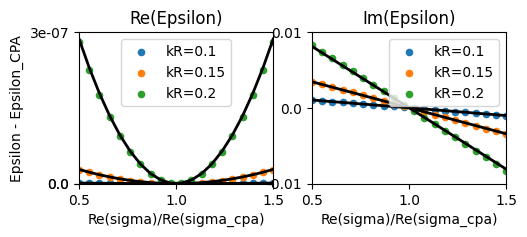

In [197]:
s = 20
linewidth = 2
ax1_min = epsilon_reals.min()
ax1_max = epsilon_reals.max()
ax2_min = epsilon_imaginaries.imag.min()
ax2_max = epsilon_imaginaries.imag.max()
cm = 1/2.54
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14*cm, 5*cm))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    ax2.plot(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx], -2*(x[cpa_idx]**3)*(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx]-1), linewidth=linewidth, color="black")
    ax1.plot(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx], epsilon+(2/5)*(sigma_reals_off_cpa_v[idx]-sigmas_real[cpa_idx])**2, linewidth=linewidth, color="black")

    ax1.scatter(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx], epsilons_real_cpa_v[idx], label=f"kR={round(x[cpa_idx], 2)}", s=s)
    ax2.scatter(sigma_reals_off_cpa_v[idx]/sigmas_real[cpa_idx], epsilons_imaginary_cpa_v[idx], label=f"kR={round(x[cpa_idx], 2)}", s=s)

ax1.legend()
ax2.legend()
ax1.set_xlim(0.5, 1.5);
ax2.set_xlim(0.5, 1.5);

ax1.set_title("Re(Epsilon)")
ax2.set_title("Im(Epsilon)")

ax1.set_xlabel("Re(sigma)/Re(sigma_cpa)")
ax2.set_xlabel("Re(sigma)/Re(sigma_cpa)");

ax2.set_ylim(ax2_min, ax2_max);
ax1.set_ylim(ax1_min, ax1_max);
ax1.set_yticks([ax1_min, epsilon, ax1_max], (np.array([ax1_min, epsilon, ax1_max]) - epsilon).round(8))
ax2.set_yticks([ax2_min, 0, ax2_max], np.array([ax2_min, 0, ax2_max]).round(5))

ax1.set_xticks([0.5, 1, 1.5]);
ax2.set_xticks([0.5, 1, 1.5]);
ax1.set_ylabel("Epsilon - Epsilon_CPA");
plt.savefig("./paper/track_imag_epsilon_off_cpa_analytic.pdf");

In [53]:
cpa_idxs = [1000]
M = int(1e3)
N = 20
tau_reshaped = tau * ones((M, M))
optimal_real_omegas_v = []
optimal_imag_omegas_v = []

for (idx, cpa_idx) in enumerate(cpa_idxs):
    print("cpa_idx: ", cpa_idx)
    hbar_omega_cpa = hbar_omega[cpa_idx]
    E_F_cpa = E_F[cpa_idx]
    a_cpa = a[cpa_idx]
    
    a_off_cpas = a_cpa*linspace(0.95, 1.05, N)
     
    optimal_real_omegas = zeros(N)
    optimal_imag_omegas = zeros(N)
    
    for (a_idx, a_off_cpa) in enumerate(a_off_cpas):
        delta_guess = -(a_off_cpa-a_cpa)/(2*a_cpa)
        omega_real_range = linspace(0.99, 1.01, M)*(1+delta_guess)*hbar_omega_cpa
        omega_imag_range = linspace(-3e-5, 3e-5, M)*hbar_omega_cpa
        hbar_omega_off_cpa = omega_real_range.reshape((M, 1)).repeat(M, axis=1) + 1j*omega_imag_range.reshape((1, M)).repeat(M, axis=0)

        x_s = hbar_omega_off_cpa * a_off_cpa/(c*hbar) # keep radius fixed
        sigmas = graphene_conductivity(E_F_cpa, hbar_omega_off_cpa, hbar/tau_reshaped, include_interband=False)
        g_omegas = sigmas*1j/x_s
        s_sqrds = abs(e_r_cpa(l, x_s, epsilon, g_omegas))**2
        print(s_sqrds.min())
        assert s_sqrds.min() < 1e-3
        row, col = unravel_index(s_sqrds.argmin(), (M, M))
        optimal_real_omegas[a_idx] = omega_real_range[row] 
        optimal_imag_omegas[a_idx] = omega_imag_range[col] 
    optimal_imag_omegas_v.append(optimal_imag_omegas)
    optimal_real_omegas_v.append(optimal_real_omegas)

cpa_idx:  1000
0.0001974648135665678
0.00016225711250930628
3.1225062983774233e-07
6.170938857522446e-05
0.0001658070736533269
0.00022102999990793493
0.0002007113261517194
0.00012316232705997615
3.552851124518492e-05
9.219116288295307e-07
8.817199258201424e-05
0.00036379014471727697
8.943338926001879e-05
5.51281352706382e-06
0.00021697624259438576
0.00011753810366049584
5.848647646004939e-06
0.0002464586464860571
7.431371432286291e-05
2.0469654390021805e-05


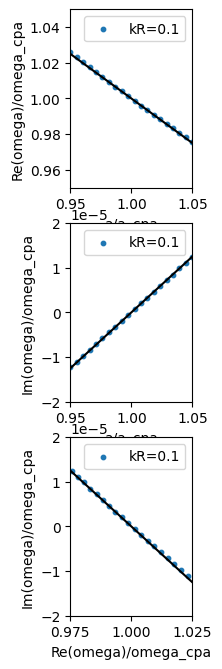

In [62]:
s=10
x_axis = linspace(0.95, 1.05, N)
cm = 1/2.54

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4*cm, 20*cm))
for (idx, cpa_idx) in enumerate(cpa_idxs):
    ax1.scatter(x_axis, optimal_real_omegas_v[idx]/hbar_omega[cpa_idx], s=s, label=f"kR={round(x[cpa_idx], 2)}")
    ax2.scatter(x_axis, optimal_imag_omegas_v[idx]/hbar_omega[cpa_idx], s=s, label=f"kR={round(x[cpa_idx], 2)}")
    ax3.scatter(optimal_real_omegas_v[idx]/hbar_omega[cpa_idx], optimal_imag_omegas_v[idx]/hbar_omega[cpa_idx], s=s, label=f"kR={round(x[cpa_idx], 2)}")
    ax1.plot(x_axis, -(1/2)*(x_axis-1)+1, color="black")
    ax2.plot(x_axis, 1/(2+epsilon)*(x_axis-1)*x[cpa_idx]**3, color="black")
    ax3.plot(-(1/2)*(x_axis-1)+1, 1/(2+epsilon)*(x_axis-1)*x[cpa_idx]**3, color="black")
ax1.set_xlabel("a/a_cpa")
ax2.set_xlabel("a/a_cpa")
ax1.set_ylabel("Re(omega)/omega_cpa")
ax2.set_ylabel("Im(omega)/omega_cpa");
ax3.set_xlabel("Re(omega)/omega_cpa")
ax3.set_ylabel("Im(omega)/omega_cpa");
ax1.set_xlim(0.95, 1.05)
ax2.set_xlim(0.95, 1.05);
ax1.set_ylim(0.95, 1.05);
ax2.set_ylim(-2e-5, 2e-5);
ax3.set_ylim(-2e-5, 2e-5);
ax3.set_xlim(0.975, 1.025);
ax1.legend();ax2.legend();ax3.legend();
plt.savefig("./paper/track_complex_frequencies_off_cpa_analytic.pdf");